# Baseline Model: Logistic Regression

## 📌 Modeling Strategy
We build models in order of increasing complexity to establish clear benchmarks:

| Step | Model | Purpose |
|------|-------|---------|
| 1 | **Logistic Regression** | Interpretable baseline |
| 2 | **Random Forest** | Non-linear, handles interactions |

Starting simple is important — if a complex model only marginally outperforms Logistic Regression, the simpler model is often preferred in production due to its interpretability and lower maintenance cost.

## 📌 What is Logistic Regression?
Despite its name, Logistic Regression is a **classification algorithm**, not a regression one. It models the **probability** that a customer belongs to a class (Churn = Yes or No) using the logistic (sigmoid) function, which maps any input to a value between 0 and 1.

It is a great baseline because:
* Fast to train and easy to interpret
* Coefficients directly show feature impact on churn probability
* Works well when relationships between features and target are approximately linear

## 📌 Modeling Pipeline:
1. Load processed data
2. Split features and target
3. Train/test split
4. Build Logistic Regression baseline
5. Evaluate and interpret results

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style = 'whitegrid')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## Load and Prepare Data

We load from `data/processed/` as this data has already been:
* Cleaned (missing values handled, data types fixed)
* Encoded (categorical variables converted to numeric)
* Feature engineered (new features added)

No further preprocessing is needed in this notebook.

In [2]:
df = pd.read_csv('/Users/chldbng/Documents/projects/customer-churn-predictor/data/processed/telco_churn_processed.csv')

print(f'✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

✅ Data loaded: 7043 rows, 34 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,charges_per_tenure,tenure_group_Established (25-48),tenure_group_Loyal (49-72),tenure_group_New (0-12),is_new_customer,is_long_term_customer,total_services,avg_charge_per_service,has_no_support,is_high_value
0,0,0,1,0,1,0,1,29.85,29.85,0,...,14.925000,False,False,True,1,0,1,14.9250,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1.627143,True,False,False,0,0,3,14.2375,0,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,17.950000,False,False,True,1,0,3,13.4625,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0.919565,True,False,False,0,0,3,10.5750,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,23.566667,False,False,True,1,0,1,35.3500,1,0


## Split Features and Target

### What is a Train/Test Split?
We divide our dataset into two subsets:
- **Training set (80%)** — the data the model learns from
- **Test set (20%)** — held-out data the model has **never seen**, used to 
  simulate real-world performance

This is critical because a model evaluated on its own training data will appear 
to perform perfectly — it has simply memorized the answers. The test set gives 
us an honest estimate of how well the model generalizes to new customers.

### Why Stratified Split?
We use `stratify=y` to ensure both train and test sets have the **same churn ratio 
(~26%)**. Without stratification, we might accidentally put most churners in one 
set, making evaluation unreliable.

In [3]:
X = df.drop(columns = ['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f'✅ Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Churn rate in train: {y_train.mean():.2%}')
print(f'Churn rate in test: {y_test.mean():.2%}')
print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeature list:')
print(X.columns.tolist())

✅ Train size: 5634 | Test size: 1409
Churn rate in train: 26.54%
Churn rate in test: 26.54%
Features shape: (7043, 33)
Target shape: (7043,)

Feature list:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'MultipleLines_Yes', 'charges_per_tenure', 'tenure_group_Established (25-48)', 'tenure_group_Loyal (49-72)', 'tenure_group_New (0-12)', 'is_new_customer', 'is_long_term_customer', 'total_services', 'avg_charge_per_service', 'has_no_support', 'is_high_value']


## Build and Train Logistic Regression

### What is a Sklearn Pipeline?
A `Pipeline` chains multiple processing steps into a single object. 
This is best practice because:
* **Prevents data leakage** — the scaler only learns from training data, not the test set
* **Simplifies deployment** — one object handles all preprocessing and prediction
* **Reduces errors** — no risk of forgetting to scale new data at inference time

### Why StandardScaler?
Logistic Regression is sensitive to the **scale of features** because it uses gradient-based optimization. Without scaling:
- `TotalCharges` (range: 0–8,000) would dominate over `SeniorCitizen` (0 or 1)
- The model would struggle to find optimal coefficients

`StandardScaler` transforms each feature to have **mean = 0 and standard deviation = 1**,  putting all features on equal footing.

### Why class_weight='balanced'?
Since only 26% of customers churned, the model would naturally bias toward predicting "No Churn" to minimize errors. Setting `class_weight='balanced'` tells the model to **penalize mistakes on the minority class (churners) more heavily**, improving recall on the class that matters most to the business.

In [4]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42))])
pipeline.fit(X_train, y_train)

print('✅ Model trained successfully')

✅ Model trained successfully


## Evaluation on Test Set

### Evaluation Metrics — Why These and Not Others?

| Metric | Definition | Why We Use It |
|--------|-----------|---------------|
| **ROC-AUC** | Area under the ROC curve — measures overall ability to rank churners above non-churners | Threshold-independent, great for imbalanced datasets |
| **Recall** | Of all actual churners, what % did we catch? | Most important — missing a churner is costly |
| **Precision** | Of all predicted churners, what % actually churned? | Measures false alarm rate |
| **F1 Score** | Harmonic mean of precision and recall | Balances both when classes are imbalanced |
| **Accuracy** | Overall % correct | **Misleading here** — predicting No Churn always gives 74% accuracy |

### Why NOT Accuracy?
If we built a model that predicted "No Churn" for every single customer, 
it would achieve **74% accuracy** just because 74% of customers didn't churn. 
This model would be completely useless for our business goal. This is why we 
prioritize **Recall and ROC-AUC** over accuracy for imbalanced classification problems.

In [5]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print('=' * 50)
print('CLASSIFICATION REPORT')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names = ['No Churn', 'Churn']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob): .4f}')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score:  0.8472


## Confusion Matrix

### What is a Confusion Matrix?
A confusion matrix shows the **breakdown of correct and incorrect predictions** across both classes:

|  | Predicted No Churn | Predicted Churn |
|--|-------------------|-----------------|
| **Actual No Churn** | True Negative (TN) ✅ | False Positive (FP) ⚠️ |
| **Actual Churn** | False Negative (FN) ❌ | True Positive (TP) ✅ |

### Business Interpretation:
- **False Negative (FN)** — We predicted a customer would stay but they churned. This is the **most costly error** — we missed a customer we could have retained.
- **False Positive (FP)** — We predicted churn but the customer stayed. This leads to unnecessary retention offers but is less harmful.

This is why we prioritize **Recall** — it directly minimizes False Negatives.

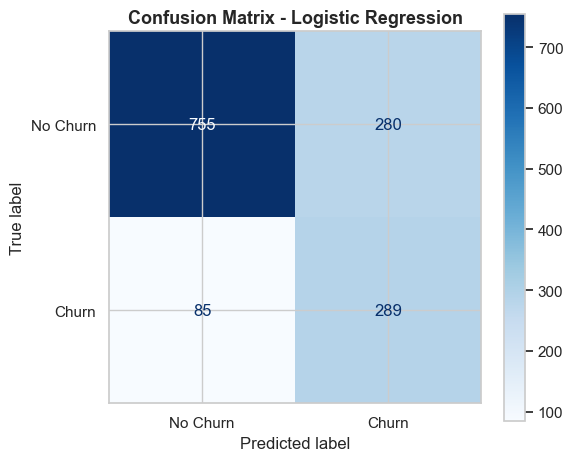

In [6]:
fig, ax = plt.subplots(figsize = (6,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels = ['No Churn', 'Churn'], cmap = 'Blues', ax = ax)

ax.set_title('Confusion Matrix - Logistic Regression', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## ROC Curve

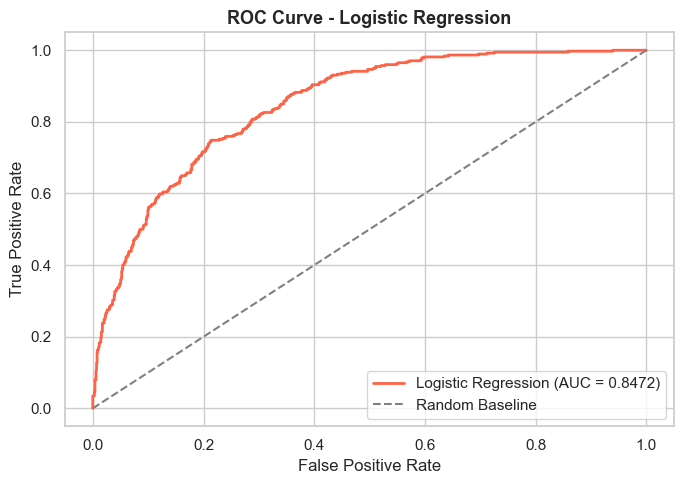

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize = (7,5))
plt.plot(fpr, tpr, color = 'tomato', lw = 2, label = f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0,1],[0,1], color = 'gray', linestyle = '--', label = 'Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression', fontsize = 13, fontweight = 'bold')
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross Validation

In [8]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

cv_auc = cross_val_score(pipeline, X, y, cv = cv, scoring = 'roc_auc')
cv_f1 = cross_val_score(pipeline, X, y, cv = cv, scoring = 'f1')

print('=' * 50)
print('5-FOLD CROSS VALIDATION RESULTS')
print('=' * 50)
print(f'ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'F1 Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

5-FOLD CROSS VALIDATION RESULTS
ROC-AUC: 0.8479 ± 0.0110
F1 Score: 0.6316 ± 0.0099


## Feature Importance

### How Logistic Regression Measures Importance
In Logistic Regression, importance is measured by **coefficients** — the weight assigned to each feature after scaling:
* **Large positive coefficient** → feature strongly increases churn probability
* **Large negative coefficient** → feature strongly decreases churn probability
* **Near zero coefficient** → feature has little influence on predictions

### ⚠️ Important Note — LR vs Random Forest Feature Importance
Feature importance is **calculated differently** across models:

| Model | Method | What It Measures |
|-------|--------|-----------------|
| **Logistic Regression** | Coefficients | Linear contribution to log-odds of churn |
| **Random Forest** | Mean Decrease in Impurity | Average reduction in node impurity across all trees |

This means the **same feature can have different importance rankings** across models.  A feature that is highly important in Logistic Regression may be less so in Random Forest if its relationship with churn is non-linear.

### Business Insights From Coefficients:
- **Positive coefficients** → these are your **churn risk factors** (e.g. month-to-month contract, fiber optic, high monthly charges)
- **Negative coefficients** → these are your **retention factors** (e.g. long tenure, two-year contract, tech support)

These insights can be directly communicated to business teams to design targeted retention strategies — for example, offering discounts to month-to-month customers or bundling tech support with fiber optic plans.

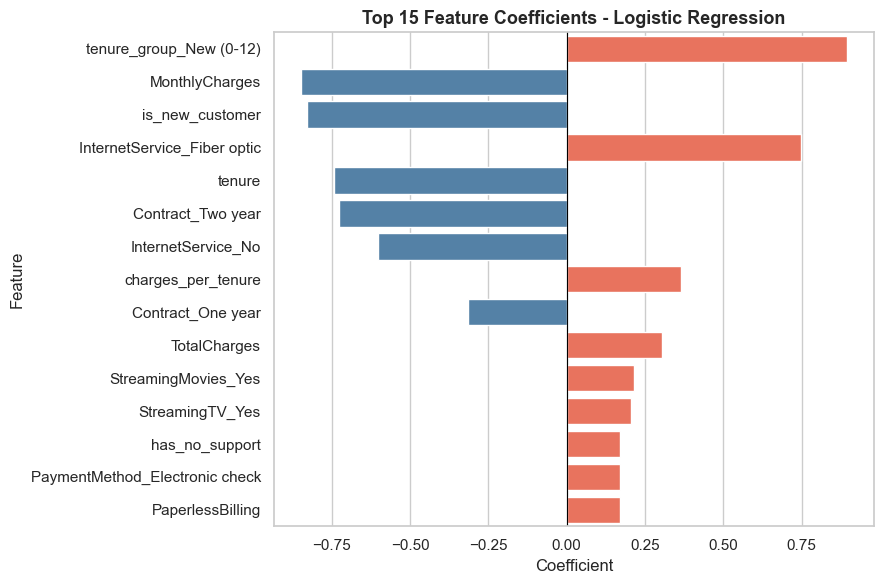

In [9]:
feature_names = X.columns.tolist()
coefficients = pipeline.named_steps['model'].coef_[0]

feat_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients}).sort_values('Coefficient', key = abs, ascending = False).head(15)

plt.figure(figsize = (9,6))
colors = ['tomato' if c > 0 else 'steelblue' for c in feat_importance['Coefficient']]
sns.barplot(feat_importance, x = 'Coefficient', y = 'Feature', palette = colors)
plt.axvline(0, color = 'black', linewidth = 0.8)
plt.title('Top 15 Feature Coefficients - Logistic Regression', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## Save the Model

In [10]:
import pickle

with open('../models/logistic_regression_baseline.pkl', 'wb') as f:pickle.dump(pipeline, f)

print('✅ Model saved to models/logistic_regression_baseline.pkl')

✅ Model saved to models/logistic_regression_baseline.pkl
